# Nodes analysis

### Phase 1: Data Preparation & Intermediate JSON (Node-Level Details)
Load Data: Load both law_references.json and ru_id.json into memory (e.g., as Python lists of dictionaries).
Build Comprehensive Node-Category Map: Create a single dictionary that maps every known node identifier (both cleaned_filename values from law_references.json and actId values from ru_id.json) to its corresponding category (category or categoryLabel).
Iterate through law_references.json: map cleaned_filename -> category.
Iterate through ru_id.json: map actId -> categoryLabel. Handle potential overlaps if necessary (though unlikely if naming is consistent). This map is crucial for looking up categories of both source and target nodes.
Process References & Create Intermediate JSON: Iterate through each document in law_references.json. For each document:
Identify the source_node (cleaned_filename) and its source_category (using the map from step 2).
Initialize counters for internal and external references for this node.
Create a list to store details about each reference made by this node.
For each target_node_id in `translated_reference_codes

In [1]:
import json
import sys
import os # Import os module for path handling

# --- Function to perform the analysis ---
def analyze_references(law_references_filepath, ru_id_filepath):
    """
    Analyzes law references from two JSON files to create an intermediate
    node-level report and identify discrepancies and unused IDs.

    Args:
        law_references_filepath (str): Path to the law_references JSON file.
        ru_id_filepath (str): Path to the ru_id JSON file.

    Returns:
        dict: A dictionary containing 'discrepancy_log', 'unused_ru_ids',
              and 'intermediate_node_data'.
        None: If files cannot be loaded.
    """
    # --- 1. Load Data ---
    try:
        with open(law_references_filepath, 'r', encoding='utf-8') as f:
            law_references_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: File not found at {law_references_filepath}")
        return None
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {law_references_filepath}")
        return None

    try:
        with open(ru_id_filepath, 'r', encoding='utf-8') as f:
            ru_id_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: File not found at {ru_id_filepath}")
        return None
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {ru_id_filepath}")
        return None

    # --- 2. Build Node-Category Map & Log Discrepancies ---
    node_category_map = {}
    discrepancy_log = []
    source_node_ids = set() # Keep track of nodes defined in law_references

    # First pass: populate map with data from law_references.json (higher priority)
    for entry in law_references_data:
        # Basic check for required keys - adjust if structure can vary
        if 'cleaned_filename' not in entry or 'category' not in entry:
            print(f"Warning: Skipping entry in {law_references_filepath} due to missing keys: {entry}")
            continue
        node_id = entry['cleaned_filename']
        category = entry['category']
        node_category_map[node_id] = category
        source_node_ids.add(node_id)

    # Second pass: add data from ru_id.json, checking for discrepancies
    ru_id_node_ids = set()
    for entry in ru_id_data:
        # Basic check for required keys
        if 'actId' not in entry or 'categoryLabel' not in entry:
            print(f"Warning: Skipping entry in {ru_id_filepath} due to missing keys: {entry}")
            continue
        act_id = entry['actId']
        category_label = entry['categoryLabel']
        ru_id_node_ids.add(act_id)
        if act_id in node_category_map:
            existing_category = node_category_map[act_id]
            if existing_category != category_label:
                discrepancy_log.append({
                    "node_id": act_id,
                    "category_law_references": existing_category,
                    "category_ru_id": category_label
                })
                # Keep the category from law_references.json as per instruction
        else:
            # Add only if not already present from law_references
            node_category_map[act_id] = category_label

    # --- 3. Generate Intermediate Node Data ---
    intermediate_data = []

    for source_doc in law_references_data:
        # Re-check for keys needed for processing this specific document
        if 'cleaned_filename' not in source_doc or 'translated_reference_codes' not in source_doc:
            print(f"Warning: Skipping processing for entry due to missing keys needed for references: {source_doc.get('original_filename', source_doc)}")
            continue

        source_node_id = source_doc['cleaned_filename']
        # Source category should always be in the map from the first pass
        # Added robustness in case the initial load/check missed something
        source_category = node_category_map.get(source_node_id)
        if not source_category:
             print(f"Critical Error: Source category not found in map for {source_node_id}. Skipping this node's references.")
             continue # Skip processing references for this node


        internal_ref_count = 0
        external_ref_count = 0
        referenced_nodes_details = []

        for target_node_id in source_doc['translated_reference_codes']:
            target_category = node_category_map.get(target_node_id)

            if target_category:
                # Category found in our map
                if target_category == source_category:
                    internal_ref_count += 1
                else:
                    external_ref_count += 1
            else:
                # Category not found - assign Unknown category
                external_ref_count += 1 # References to unknown are external
                if isinstance(target_node_id, str) and target_node_id.startswith("RU"):
                     target_category = "Unknown RU"
                elif isinstance(target_node_id, str) and target_node_id.startswith("FF"):
                     target_category = "Unknown FF"
                else:
                     target_category = "Unknown" # Fallback for unexpected formats

            referenced_nodes_details.append({
                "id": target_node_id,
                "category": target_category
            })

        intermediate_data.append({
            "source_node_id": source_node_id,
            "source_category": source_category,
            "references": referenced_nodes_details,
            "internal_reference_count": internal_ref_count,
            "external_reference_count": external_ref_count
        })

    # --- 4. Identify Unused RU IDs ---
    # Find actIds from ru_id.json that were not present as cleaned_filename in law_references.json
    unused_ru_ids = sorted(list(ru_id_node_ids - source_node_ids)) # Sort for consistent output

    # --- 5. Prepare Results ---
    results = {
        "discrepancy_log": discrepancy_log,
        "unused_ru_ids": unused_ru_ids,
        "intermediate_node_data": intermediate_data
    }
    return results

# --- Main execution block ---
if __name__ == "__main__":
    # --- !! IMPORTANT: Replace with the actual paths to your JSON files !! ---
    law_refs_path = "./scripts/PDF Articles/swiss_law_references_translated_v3.json"
    ru_id_path = "./raw_data/RU_Id and Types.json"
    output_path = "./raw_data/intermediate_analysis_results.json" # Path to save the output

    # --- Create dummy files for demonstration if they don't exist ---
    # (You should replace this section with your actual files)
    if not os.path.exists(law_refs_path):
        print(f"Creating dummy file: {law_refs_path}")
        dummy_law_refs_data = [
            {"original_filename": "dummy-1.pdf", "category": "Cat A", "cleaned_filename": "FF 1", "translated_reference_codes": ["FF 2", "RU 1"], "missing_rs_codes": []},
            {"original_filename": "dummy-2.pdf", "category": "Cat B", "cleaned_filename": "FF 2", "translated_reference_codes": ["RU 1", "RU 2", "FF 99"], "missing_rs_codes": []},
            {"original_filename": "dummy-3.pdf", "category": "Cat A", "cleaned_filename": "RU 1", "translated_reference_codes": ["RU 2"], "missing_rs_codes": []}
        ]
        with open(law_refs_path, 'w', encoding='utf-8') as f:
            json.dump(dummy_law_refs_data, f, indent=4, ensure_ascii=False)

    if not os.path.exists(ru_id_path):
        print(f"Creating dummy file: {ru_id_path}")
        dummy_ru_id_data = [
            {"actId": "RU 1", "categoryLabel": "Cat A"},
            {"actId": "RU 2", "categoryLabel": "Cat B"},
            {"actId": "RU 3", "categoryLabel": "Cat C"}
        ]
        with open(ru_id_path, 'w', encoding='utf-8') as f:
            json.dump(dummy_ru_id_data, f, indent=4, ensure_ascii=False)
    # --- End of dummy file creation ---


    print(f"Analyzing references using:")
    print(f"  Law References: {os.path.abspath(law_refs_path)}")
    print(f"  RU IDs: {os.path.abspath(ru_id_path)}")

    analysis_results = analyze_references(law_refs_path, ru_id_path)

    if analysis_results:
        print(f"\nAnalysis complete. Saving results to: {os.path.abspath(output_path)}")
        try:
            # Save the results to a JSON file
            with open(output_path, 'w', encoding='utf-8') as f:
                json.dump(analysis_results, f, indent=4, ensure_ascii=False)
            print("Results saved successfully.")

            # Optionally print a summary or parts of the result to the console
            print(f"\nDiscrepancy Log Entries: {len(analysis_results['discrepancy_log'])}")
            # print(json.dumps(analysis_results['discrepancy_log'], indent=4, ensure_ascii=False)) # Uncomment to print log
            print(f"Unused RU IDs Count: {len(analysis_results['unused_ru_ids'])}")
            # print(f"Unused RU IDs: {analysis_results['unused_ru_ids']}") # Uncomment to print list
            print(f"Processed Source Nodes: {len(analysis_results['intermediate_node_data'])}")
            # print(json.dumps(analysis_results['intermediate_node_data'][:2], indent=4, ensure_ascii=False)) # Print first 2 entries as sample

        except IOError as e:
            print(f"Error saving results to {output_path}: {e}")
        except Exception as e:
            print(f"An unexpected error occurred during saving: {e}")

Analyzing references using:
  Law References: ./scripts/PDF Articles/swiss_law_references_translated_v3.json
  RU IDs: ./raw_data/RU_Id and Types.json

Analysis complete. Saving results to: ./raw_data/intermediate_analysis_results.json
Results saved successfully.

Discrepancy Log Entries: 97
Unused RU IDs Count: 26589
Processed Source Nodes: 21641


### Step 2: aggregating the intermediate data to create the final JSON summary by category.
This script will:
Load the intermediate data generated in the previous step (assuming it was saved to intermediate_analysis_results.json).
Aggregate the counts:
Count the total number of source nodes per category.
Sum the total internal references per source category.
Count external references, grouping them by the target category for each source category.
Format the results into the final desired JSON structure.
Save the final summary to a new JSON file.

In [2]:
import json
import os
from collections import defaultdict # Useful for nested dictionaries

# --- Function to aggregate intermediate data ---
def aggregate_by_category(intermediate_data):
    """
    Aggregates the node-level reference data into a category-level summary.

    Args:
        intermediate_data (list): The list of dictionaries generated by the
                                   previous analysis step ('intermediate_node_data').

    Returns:
        list: A list of dictionaries, where each dictionary summarizes a source category's
              referencing behavior (node count, internal refs, external refs by target cat).
    """
    category_summary = {} # Use dict for easy access by category name during processing

    # Iterate through each source node's data
    for node_info in intermediate_data:
        source_category = node_info.get('source_category')
        references = node_info.get('references', [])

        # Skip if essential info is missing for some reason
        if not source_category:
            print(f"Warning: Skipping node data due to missing source category: {node_info.get('source_node_id', 'Unknown ID')}")
            continue

        # Initialize category entry if first time seeing it
        if source_category not in category_summary:
            category_summary[source_category] = {
                "node_count": 0,
                "total_internal_references": 0,
                "external_references_by_target_category": defaultdict(int) # Use defaultdict for easier counting
            }

        # Increment node count for this category
        category_summary[source_category]["node_count"] += 1

        # Process references made by this node
        for ref in references:
            target_category = ref.get('category')
            if not target_category:
                 print(f"Warning: Skipping reference with missing target category from node {node_info.get('source_node_id', 'Unknown ID')}: {ref.get('id', 'Unknown Target ID')}")
                 continue # Skip this specific reference

            # Check if internal or external
            if target_category == source_category:
                category_summary[source_category]["total_internal_references"] += 1
            else:
                # Increment count for this specific target category within the external refs
                category_summary[source_category]["external_references_by_target_category"][target_category] += 1

    # Format the output into the desired list of dictionaries
    final_summary_list = []
    for category_name, summary_data in category_summary.items():
        # Convert defaultdict back to regular dict for JSON serialization if needed,
        # though json.dumps handles defaultdict correctly. Sort external refs for consistency.
        sorted_external_refs = dict(sorted(summary_data["external_references_by_target_category"].items()))

        final_summary_list.append({
            "category_name": category_name,
            "node_count": summary_data["node_count"],
            "total_internal_references": summary_data["total_internal_references"],
            "external_references_by_target_category": sorted_external_refs
        })

    # Sort the final list by category name for consistent output
    final_summary_list.sort(key=lambda x: x["category_name"])

    return final_summary_list


# --- Main execution block ---
if __name__ == "__main__":
    # --- Paths ---
    # !! IMPORTANT: Make sure this path points to the output of the previous script !!
    intermediate_results_path = "./raw_data/intermediate_analysis_results.json"
    # Path to save the final category summary
    final_summary_output_path = "./raw_data/final_category_summary.json"

    # --- Load Intermediate Data ---
    print(f"Loading intermediate analysis results from: {os.path.abspath(intermediate_results_path)}")
    intermediate_node_data = None
    try:
        with open(intermediate_results_path, 'r', encoding='utf-8') as f:
            # Load the entire structure first
            full_intermediate_results = json.load(f)
            # Extract the relevant part
            intermediate_node_data = full_intermediate_results.get("intermediate_node_data")

            if intermediate_node_data is None:
                 print(f"Error: Key 'intermediate_node_data' not found in {intermediate_results_path}")
            elif not isinstance(intermediate_node_data, list):
                 print(f"Error: 'intermediate_node_data' in {intermediate_results_path} is not a list.")
                 intermediate_node_data = None # Reset to prevent processing incorrect data type

    except FileNotFoundError:
        print(f"Error: Intermediate results file not found at {intermediate_results_path}")
        print("Please run the first script (analyze_laws.py) to generate it.")
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {intermediate_results_path}")
    except Exception as e:
        print(f"An unexpected error occurred during loading: {e}")


    # --- Aggregate Data ---
    if intermediate_node_data:
        print("Aggregating data by category...")
        final_summary = aggregate_by_category(intermediate_node_data)

        # --- Save Final Summary ---
        print(f"Aggregation complete. Saving final summary to: {os.path.abspath(final_summary_output_path)}")
        try:
            with open(final_summary_output_path, 'w', encoding='utf-8') as f:
                json.dump(final_summary, f, indent=4, ensure_ascii=False)
            print("Final summary saved successfully.")

            # Optionally print the summary to console
            # print("\n--- Final Category Summary ---")
            # print(json.dumps(final_summary, indent=4, ensure_ascii=False))
            # print("--- End of Summary ---")

        except IOError as e:
            print(f"Error saving final summary to {final_summary_output_path}: {e}")
        except Exception as e:
            print(f"An unexpected error occurred during saving the final summary: {e}")
    else:
        print("Cannot proceed with aggregation due to issues loading intermediate data.")

Loading intermediate analysis results from: ./raw_data/intermediate_analysis_results.json
Aggregating data by category...
Aggregation complete. Saving final summary to: ./raw_data/final_category_summary.json
Final summary saved successfully.


# Step 3: visualization


#### Load the data

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import plotly.graph_objects as go
from collections import defaultdict
import math # For node sizing calculations

# --- Configuration ---
SUMMARY_FILE_PATH = "./raw_data/final_category_summary.json"
OUTPUT_DIR = "visualizations" # Directory to save plots

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Load Data ---
def load_summary_data(filepath):
    """Loads the final category summary data from a JSON file."""
    print(f"Loading summary data from: {filepath}")
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
        if not isinstance(data, list):
            print("Error: Summary data should be a list of category objects.")
            return None
        print(f"Successfully loaded {len(data)} category summaries.")
        return data
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return None
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {filepath}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred during loading: {e}")
        return None

# Load the data once
summary_data = load_summary_data(SUMMARY_FILE_PATH)

# If data loading failed, stop here
if summary_data is None:
    print("Exiting due to data loading failure.")
    exit()

# --- Helper Function for filename ---
def get_safe_filename(name, suffix=".png"):
    """Creates a safe filename by removing invalid characters."""
    # Keep alphanumeric, underscore, hyphen. Replace space with _. Limit length.
    safe_name = "".join(c for c in name if c.isalnum() or c in ('_', '-')).rstrip()
    safe_name = safe_name.replace(' ', '_')
    return os.path.join(OUTPUT_DIR, safe_name[:50] + suffix) # Limit length

Loading summary data from: ./raw_data/final_category_summary.json
Successfully loaded 33 category summaries.


### Simplified Network Diagram

In [10]:
# Replace the previous create_network_diagram function with this one

# --- 1. Simplified Network Diagram (REVISED) ---
def create_network_diagram(data, top_n_nodes=None, min_edge_weight=1, filename="network_diagram_revised.png"):
    """
    Creates a (revised) simplified network diagram with better layout and colors.

    Args:
        data (list): The summary data loaded from JSON.
        top_n_nodes (int, optional): Show only top N categories by node_count. Defaults to None (show all).
        min_edge_weight (int, optional): Show only edges (references) >= this value. Defaults to 1.
        filename (str, optional): Output filename. Defaults to "network_diagram_revised.png".
    """
    print(f"\nGenerating REVISED Network Diagram (Top N={top_n_nodes}, Min Edge={min_edge_weight})...")

    if top_n_nodes:
        data = sorted(data, key=lambda x: x.get('node_count', 0), reverse=True)[:top_n_nodes]
        categories_to_show = {item['category_name'] for item in data}
        print(f"  Showing top {len(categories_to_show)} categories.")
    else:
        categories_to_show = {item['category_name'] for item in data}
        print("  Showing all categories.")

    G = nx.DiGraph()
    node_data = {} # Store data associated with nodes

    # Add nodes first
    for item in data:
        cat_name = item['category_name']
        node_count = item.get('node_count', 1)
        node_data[cat_name] = {'node_count': node_count}
        G.add_node(cat_name) # Add node to graph

    print(f"  Added {G.number_of_nodes()} nodes.")
    if G.number_of_nodes() == 0:
        print("  No nodes to draw. Skipping plot generation.")
        return

    # Calculate node sizes *after* all nodes are added and we know the range
    node_counts = [node_data[node]['node_count'] for node in G.nodes()]
    min_count = min(node_counts) if node_counts else 1
    max_count = max(node_counts) if node_counts else 1
    # Apply scaling - using sqrt reduces disparity, adjust base_size and multiplier
    base_size = 200
    multiplier = 1500 # Reduced significantly from original
    node_sizes = [base_size + multiplier * (math.sqrt(nc) - math.sqrt(min_count)) / (math.sqrt(max_count) - math.sqrt(min_count) + 1e-6)
                  for nc in node_counts] # Normalize sqrt(count) and scale

    # Node labels
    node_labels = {node: f"{node}\n(Nodes: {node_data[node]['node_count']})" for node in G.nodes()}


    edges_added = 0
    # Add edges based on references
    for item in data:
        source_cat = item['category_name']
        if source_cat not in G: continue # Skip if source wasn't included (e.g., due to top_n)

        # Internal references (self-loops)
        internal_refs = item.get('total_internal_references', 0)
        if internal_refs >= min_edge_weight:
            G.add_edge(source_cat, source_cat, weight=internal_refs, type='internal')
            edges_added +=1

        # External references
        external_refs = item.get('external_references_by_target_category', {})
        for target_cat, count in external_refs.items():
            # Only add edge if target exists in the graph (respects top_n)
            # and weight is sufficient
            if target_cat in G and count >= min_edge_weight:
                 if source_cat != target_cat:
                    G.add_edge(source_cat, target_cat, weight=count, type='external')
                    edges_added += 1

    print(f"  Added {edges_added} edges (>= {min_edge_weight} refs).")

    # --- Plotting ---
    plt.figure(figsize=(18, 14)) # Slightly larger figure

    # Use Kamada-Kawai layout for better spacing
    # Compute layout only for the main component if graph is not connected
    if nx.is_connected(G.to_undirected()):
         pos = nx.kamada_kawai_layout(G)
    else:
         print("  Graph is not connected, using spring_layout as fallback.")
         # Or compute layout component by component - simpler fallback for now:
         pos = nx.spring_layout(G, k=0.8, iterations=50, seed=42)


    # Get node colors from a palette
    colors = plt.cm.Paired # Choose a colormap (e.g., Paired, Set3, viridis)
    node_colors = [colors(i / G.number_of_nodes()) for i in range(G.number_of_nodes())]

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)

    # Separate edges by type for different styling
    external_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'external']
    internal_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'internal']

    # Get edge weights for scaling width
    external_widths = [G[u][v]['weight'] for u, v in external_edges]
    internal_widths = [G[u][v]['weight'] for u, v in internal_edges]

    # Scale widths (adjust multiplier as needed)
    external_widths_scaled = [0.5 + w * 0.3 for w in external_widths]
    internal_widths_scaled = [0.5 + w * 0.3 for w in internal_widths]

    # Draw external edges
    nx.draw_networkx_edges(G, pos, edgelist=external_edges, width=external_widths_scaled,
                           alpha=0.4, edge_color='darkgrey', arrows=True, arrowsize=15,
                           connectionstyle='arc3,rad=0.1') # Use arcs slightly

    # Draw internal edges (self-loops)
    nx.draw_networkx_edges(G, pos, edgelist=internal_edges, width=internal_widths_scaled,
                           edge_color='orange', alpha=0.6, arrows=False, # Arrows on loops look messy
                           connectionstyle='arc3,rad=0.1') # Might need adjustment


    # Draw labels
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_weight='bold')


    plt.title(f"Category Reference Network (Top {top_n_nodes or 'All'} Nodes, Min Edge Weight {min_edge_weight})", fontsize=16)
    plt.axis('off')
    plt.tight_layout() # Apply tight layout

    output_path = get_safe_filename(filename, ".png")
    plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white') # Ensure white background
    print(f"  Revised network diagram saved to: {output_path}")
    plt.close()

# --- (Keep the rest of your script, including the initial data loading) ---

# --- Call the revised function (make sure summary_data is loaded) ---
if summary_data:
    create_network_diagram(summary_data, top_n_nodes=10, min_edge_weight=2, filename="network_top10_min2_revised")
    # create_network_diagram(summary_data, filename="network_all_revised") # Optional: run for all nodes
else:
    print("Skipping visualization generation as data loading failed.")


Generating REVISED Network Diagram (Top N=10, Min Edge=2)...
  Showing top 10 categories.
  Added 10 nodes.
  Added 83 edges (>= 2 refs).


/tmp/ipykernel_3202602/2420460699.py:115: UserWarning:



The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.




  Revised network diagram saved to: visualizations/network_top10_min2_revised.png


### 2. Stacked Bar Chart

In [3]:
# --- 2. Stacked Bar Chart ---
def create_stacked_bar_chart(data, filename="stacked_bar_internal_external.png"):
    """
    Creates a stacked bar chart showing internal vs. external references per category.

    Args:
        data (list): The summary data loaded from JSON.
        filename (str, optional): Output filename. Defaults to "stacked_bar_internal_external.png".
    """
    print("\nGenerating Stacked Bar Chart...")

    # Sort data for consistent chart order (e.g., by category name)
    data = sorted(data, key=lambda x: x['category_name'])

    categories = [item['category_name'] for item in data]
    internal_refs = [item.get('total_internal_references', 0) for item in data]
    external_refs = [sum(item.get('external_references_by_target_category', {}).values()) for item in data]

    if not categories:
        print("  No categories found in data. Skipping chart generation.")
        return

    df = pd.DataFrame({
        'Category': categories,
        'Internal Refs': internal_refs,
        'External Refs': external_refs
    })

    plt.figure(figsize=(12, max(6, len(categories) * 0.5))) # Adjust height based on number of categories

    # Create stacked bars
    plt.barh(df['Category'], df['Internal Refs'], label='Internal References', color='steelblue')
    plt.barh(df['Category'], df['External Refs'], left=df['Internal Refs'], label='External References', color='lightcoral')

    plt.xlabel("Number of References")
    plt.ylabel("Source Category")
    plt.title("Internal vs. External References Originating From Each Category")
    plt.legend(loc='lower right')
    plt.gca().invert_yaxis() # Display categories top-to-bottom alphabetically
    plt.tight_layout() # Adjust layout

    # Add value labels (optional, can get crowded)
    for index, (internal, external) in enumerate(zip(df['Internal Refs'], df['External Refs'])):
         if internal > 0:
             plt.text(internal / 2, index, str(internal), ha='center', va='center', color='white', fontsize=8)
         if external > 0:
             plt.text(internal + external / 2, index, str(external), ha='center', va='center', color='black', fontsize=8)
         # Add total label at the end
         total = internal + external
         if total > 0:
             plt.text(total, index, f' {total}', ha='left', va='center', color='black', fontsize=8, fontweight='bold')


    output_path = get_safe_filename(filename, ".png")
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"  Stacked bar chart saved to: {output_path}")
    plt.close()

# --- Call the function ---
create_stacked_bar_chart(summary_data)


Generating Stacked Bar Chart...
  Stacked bar chart saved to: visualizations/stacked_bar_internal_externalpng.png


### Sankey Diagram

In [7]:
# --- 3. Sankey Diagram ---
def create_sankey_diagram(data, filename="sankey_references.png", title="Reference Flow Between Categories"):
    """
    Creates a Sankey diagram showing the flow of references between categories.

    Args:
        data (list): The summary data loaded from JSON.
        filename (str, optional): Output filename. Defaults to "sankey_references.png". Use .html for interactive.
        title (str, optional): Title for the diagram.
    """
    print("\nGenerating Sankey Diagram...")

    all_categories = set()
    links = []

    # Collect all category names and prepare links
    for item in data:
        source_cat = item['category_name']
        all_categories.add(source_cat)

        # Internal references
        internal_refs = item.get('total_internal_references', 0)
        if internal_refs > 0:
            links.append({'source': source_cat, 'target': source_cat, 'value': internal_refs})

        # External references
        external_refs = item.get('external_references_by_target_category', {})
        for target_cat, count in external_refs.items():
            if count > 0:
                 all_categories.add(target_cat) # Ensure target category is included
                 links.append({'source': source_cat, 'target': target_cat, 'value': count})

    if not links:
        print("  No reference links found with value > 0. Skipping Sankey diagram generation.")
        return

    # Create mapping from category name to index
    category_list = sorted(list(all_categories))
    category_to_index = {name: i for i, name in enumerate(category_list)}

    # Prepare data for Plotly Sankey
    sankey_sources = []
    sankey_targets = []
    sankey_values = []

    for link in links:
        source_idx = category_to_index.get(link['source'])
        target_idx = category_to_index.get(link['target'])
        value = link['value']

        # Skip if a category name somehow wasn't mapped (shouldn't happen)
        if source_idx is not None and target_idx is not None and value > 0:
            sankey_sources.append(source_idx)
            sankey_targets.append(target_idx)
            sankey_values.append(value)

    # Define node colors (optional) - cycle through Plotly defaults otherwise
    # colors = px.colors.qualitative.Plotly # Get plotly default colors

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=category_list,
            # color=[colors[i % len(colors)] for i in range(len(category_list))] # Assign colors
        ),
        link=dict(
            source=sankey_sources,
            target=sankey_targets,
            value=sankey_values,
            # Add hover info
            hovertemplate='%{source.label} → %{target.label}: %{value} references<extra></extra>'
        )
    )])

    fig.update_layout(title_text=title, font_size=10)

    output_path = get_safe_filename(filename)
    # Save as static image (requires kaleido: pip install -U kaleido)
    # Or save as interactive HTML
    if output_path.endswith(".png") or output_path.endswith(".jpg"):
         try:
             fig.write_image(output_path, scale=2) # Increase scale for better resolution
             print(f"  Sankey diagram saved to: {output_path}")
         except ValueError as e:
              print(f"  Error saving static Sankey image: {e}")
              print("  Make sure 'kaleido' is installed (`pip install -U kaleido`)")
              output_path_html = get_safe_filename(filename, ".html")
              fig.write_html(output_path_html)
              print(f"  Saved interactive Sankey diagram as HTML instead: {output_path_html}")

    else: # Assume HTML output
        fig.write_html(output_path)
        print(f"  Interactive Sankey diagram saved to: {output_path}")


# --- Call the function ---
create_sankey_diagram(summary_data, filename="sankey_references.png")
# create_sankey_diagram(summary_data, filename="sankey_references.html") # Example for HTML


Generating Sankey Diagram...
  Error saving static Sankey image: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

  Make sure 'kaleido' is installed (`pip install -U kaleido`)
  Saved interactive Sankey diagram as HTML instead: visualizations/sankey_referencespng.html


### Key Metrics Table

In [8]:
# --- 4. Key Metrics Table ---
def create_metrics_table(data, filename="key_metrics_table.csv"):
    """
    Creates a table (Pandas DataFrame) summarizing key metrics per category.

    Args:
        data (list): The summary data loaded from JSON.
        filename (str, optional): Output filename for CSV. Defaults to "key_metrics_table.csv".
                                  Set to None to only print.
    """
    print("\nGenerating Key Metrics Table...")

    table_data = []
    for item in data:
        source_cat = item['category_name']
        node_count = item.get('node_count', 0)
        internal_refs = item.get('total_internal_references', 0)
        external_refs_dict = item.get('external_references_by_target_category', {})
        total_external_refs = sum(external_refs_dict.values())
        total_refs = internal_refs + total_external_refs

        # Find top external target
        top_external_target = ""
        max_external_refs = 0
        if external_refs_dict:
            top_external_target = max(external_refs_dict, key=external_refs_dict.get)
            max_external_refs = external_refs_dict[top_external_target]
            top_external_target = f"{top_external_target} ({max_external_refs})"


        table_data.append({
            "Category": source_cat,
            "Node Count": node_count,
            "Internal Refs": internal_refs,
            "Total External Refs": total_external_refs,
            "Total Refs": total_refs,
            "% Internal": f"{internal_refs / total_refs:.1%}" if total_refs > 0 else "N/A",
            "Top External Target": top_external_target if top_external_target else "None"
        })

    if not table_data:
        print("  No data to create table.")
        return

    df = pd.DataFrame(table_data)
    df = df.sort_values(by="Node Count", ascending=False) # Sort by node count

    print("--- Key Metrics ---")
    print(df.to_string(index=False)) # Print formatted table to console
    print("--- End of Table ---")

    if filename:
        output_path = get_safe_filename(filename, ".csv")
        try:
            df.to_csv(output_path, index=False, encoding='utf-8-sig') # Use utf-8-sig for Excel compatibility
            print(f"  Metrics table saved to: {output_path}")
        except IOError as e:
            print(f"  Error saving table to CSV: {e}")

# --- Call the function ---
create_metrics_table(summary_data)
create_metrics_table(summary_data, filename=None) # Example to only print


Generating Key Metrics Table...
--- Key Metrics ---
                                                                     Category  Node Count  Internal Refs  Total External Refs  Total Refs % Internal                          Top External Target
                                             Ordinanza del Consiglio federale        6016           8878                 7742       16620      53.4%                        Legge federale (4691)
                                                 Ordinanza di un dipartimento        3606           1915                 4522        6437      29.7%      Ordinanza del Consiglio federale (1924)
                                                      Ordinanza di un'ufficio        2953           1023                 4314        5337      19.2%      Ordinanza del Consiglio federale (1640)
                                                         Campo d'applicazione        2869            867                 2969        3836      22.6%                       

In [2]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import plotly.graph_objects as go
from collections import defaultdict
import math

# --- Configuration ---
SUMMARY_FILE_PATH = "./raw_data/final_category_summary.json"
OUTPUT_DIR = "visualizations_top10" # New directory for focused plots
NUM_TOP_CATEGORIES = 10 # Define the number of top categories

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Load Data ---
def load_summary_data(filepath):
    """Loads the final category summary data from a JSON file."""
    print(f"Loading summary data from: {filepath}")
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
        if not isinstance(data, list):
            print("Error: Summary data should be a list of category objects.")
            return None
        print(f"Successfully loaded {len(data)} category summaries.")
        return data
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return None
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {filepath}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred during loading: {e}")
        return None

# --- Helper Function for filename ---
def get_safe_filename(name, suffix=".png"):
    """Creates a safe filename by removing invalid characters."""
    safe_name = "".join(c for c in name if c.isalnum() or c in ('_', '-')).rstrip()
    safe_name = safe_name.replace(' ', '_')
    return os.path.join(OUTPUT_DIR, safe_name[:50] + suffix)

# --- Load the full data ---
full_summary_data = load_summary_data(SUMMARY_FILE_PATH)

# --- Filter for Top N Categories ---
top_n_summary_data = None
if full_summary_data:
    # Sort by node_count descending
    full_summary_data.sort(key=lambda x: x.get('node_count', 0), reverse=True)
    # Select top N
    top_n_summary_data = full_summary_data[:NUM_TOP_CATEGORIES]
    print(f"\nFiltered data to top {len(top_n_summary_data)} categories based on node_count.")
    # Get the names of the top categories for filtering links later
    top_category_names = {item['category_name'] for item in top_n_summary_data}
else:
    print("Exiting due to data loading failure.")
    exit()


# --- Visualization Functions (Modified where necessary) ---

# 1. Simplified Network Diagram (Removed top_n_nodes parameter)
def create_network_diagram(data, min_edge_weight=1, filename="network_diagram_top10.png"):
    """
    Creates a (revised) simplified network diagram for the provided data subset.
    Assumes data is already filtered (e.g., top N).

    Args:
        data (list): The filtered summary data.
        min_edge_weight (int, optional): Show only edges (references) >= this value. Defaults to 1.
        filename (str, optional): Output filename. Defaults to "network_diagram_top10.png".
    """
    print(f"\nGenerating Network Diagram (Min Edge={min_edge_weight})...")
    # Categories to show are implicitly defined by the input 'data' list
    categories_in_data = {item['category_name'] for item in data}
    print(f"  Displaying {len(categories_in_data)} categories.")

    G = nx.DiGraph()
    node_data = {}

    # Add nodes first
    for item in data:
        cat_name = item['category_name']
        node_count = item.get('node_count', 1)
        node_data[cat_name] = {'node_count': node_count}
        G.add_node(cat_name)

    print(f"  Added {G.number_of_nodes()} nodes.")
    if G.number_of_nodes() == 0:
        print("  No nodes to draw. Skipping plot generation.")
        return

    # Calculate node sizes
    node_counts = [node_data[node]['node_count'] for node in G.nodes()]
    min_count = min(node_counts) if node_counts else 1
    max_count = max(node_counts) if node_counts else 1
    base_size = 200
    multiplier = 1500
    node_sizes = [base_size + multiplier * (math.sqrt(nc) - math.sqrt(min_count)) / (math.sqrt(max_count) - math.sqrt(min_count) + 1e-6)
                  for nc in node_counts]

    node_labels = {node: f"{node}\n(Nodes: {node_data[node]['node_count']})" for node in G.nodes()}

    edges_added = 0
    # Add edges based on references
    for item in data:
        source_cat = item['category_name']
        if source_cat not in G: continue # Should not happen if data is consistent

        # Internal references
        internal_refs = item.get('total_internal_references', 0)
        if internal_refs >= min_edge_weight:
            G.add_edge(source_cat, source_cat, weight=internal_refs, type='internal')
            edges_added +=1

        # External references - IMPORTANT: Only add if target is ALSO in the filtered data
        external_refs = item.get('external_references_by_target_category', {})
        for target_cat, count in external_refs.items():
            # Check if target category is in the ones we are displaying
            if target_cat in categories_in_data and count >= min_edge_weight:
                 if source_cat != target_cat:
                    G.add_edge(source_cat, target_cat, weight=count, type='external')
                    edges_added += 1

    print(f"  Added {edges_added} edges (>= {min_edge_weight} refs, connecting displayed nodes).")

    # --- Plotting (Identical to previous revised version) ---
    plt.figure(figsize=(18, 14))

    if nx.is_connected(G.to_undirected()):
         pos = nx.kamada_kawai_layout(G)
    else:
         print("  Graph is not connected, using spring_layout as fallback.")
         pos = nx.spring_layout(G, k=0.8, iterations=50, seed=42)

    colors = plt.cm.Paired
    node_colors = [colors(i / G.number_of_nodes()) for i in range(G.number_of_nodes())]
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)

    external_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'external']
    internal_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'internal']
    external_widths = [G[u][v]['weight'] for u, v in external_edges]
    internal_widths = [G[u][v]['weight'] for u, v in internal_edges]
    external_widths_scaled = [0.5 + w * 0.3 for w in external_widths]
    internal_widths_scaled = [0.5 + w * 0.3 for w in internal_widths]

    nx.draw_networkx_edges(G, pos, edgelist=external_edges, width=external_widths_scaled,
                           alpha=0.4, edge_color='darkgrey', arrows=True, arrowsize=15,
                           connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(G, pos, edgelist=internal_edges, width=internal_widths_scaled,
                           edge_color='orange', alpha=0.6, arrows=False,
                           connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_weight='bold')

    plt.title(f"Top {len(data)} Category Reference Network (Min Edge Weight {min_edge_weight})", fontsize=16)
    plt.axis('off')
    plt.tight_layout()

    output_path = get_safe_filename(filename, ".png")
    plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"  Network diagram saved to: {output_path}")
    plt.close()


# 2. Stacked Bar Chart (No changes needed, just pass filtered data)
def create_stacked_bar_chart(data, filename="stacked_bar_internal_external_top10.png"):
    """
    Creates a stacked bar chart showing internal vs. external references for the provided data subset.

    Args:
        data (list): The filtered summary data.
        filename (str, optional): Output filename. Defaults to "stacked_bar_internal_external_top10.png".
    """
    print("\nGenerating Stacked Bar Chart...")
    # Sort data for consistent chart order (e.g., by category name or original rank)
    # Here, using category name for the y-axis labels
    plot_data = sorted(data, key=lambda x: x['category_name'])

    categories = [item['category_name'] for item in plot_data]
    internal_refs = [item.get('total_internal_references', 0) for item in plot_data]
    # Calculate external refs SUM for the bar, even if targets are outside top 10
    external_refs = [sum(item.get('external_references_by_target_category', {}).values()) for item in plot_data]

    if not categories:
        print("  No categories found in data. Skipping chart generation.")
        return

    df = pd.DataFrame({
        'Category': categories,
        'Internal Refs': internal_refs,
        'External Refs': external_refs
    })

    plt.figure(figsize=(12, max(6, len(categories) * 0.5)))

    plt.barh(df['Category'], df['Internal Refs'], label='Internal References', color='steelblue')
    plt.barh(df['Category'], df['External Refs'], left=df['Internal Refs'], label='External References', color='lightcoral')

    plt.xlabel("Number of References")
    plt.ylabel("Source Category")
    plt.title(f"Internal vs. External References Originating From Top {len(data)} Categories")
    plt.legend(loc='lower right')
    plt.gca().invert_yaxis()
    plt.tight_layout()

    # Add value labels (optional)
    for index, (internal, external) in enumerate(zip(df['Internal Refs'], df['External Refs'])):
         if internal > 0: plt.text(internal / 2, index, str(internal), ha='center', va='center', color='white', fontsize=8)
         if external > 0: plt.text(internal + external / 2, index, str(external), ha='center', va='center', color='black', fontsize=8)
         total = internal + external
         if total > 0: plt.text(total, index, f' {total}', ha='left', va='center', color='black', fontsize=8, fontweight='bold')

    output_path = get_safe_filename(filename, ".png")
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"  Stacked bar chart saved to: {output_path}")
    plt.close()


# 3. Sankey Diagram (Modified to filter links)
def create_sankey_diagram(data, top_category_names_set, filename="sankey_references_top10.png", title=None):
    """
    Creates a Sankey diagram showing the flow of references *between* the top categories.

    Args:
        data (list): The filtered summary data (top N categories).
        top_category_names_set (set): A set containing the names of the categories in 'data'.
        filename (str, optional): Output filename. Defaults to "sankey_references_top10.png".
        title (str, optional): Title for the diagram. Defaults to dynamic title.
    """
    print("\nGenerating Sankey Diagram (Flow between Top Categories)...")

    links = []
    # The nodes are implicitly the categories present in the filtered 'data'
    category_list = sorted([item['category_name'] for item in data]) # These are our nodes

    # Collect links *only* between these top categories
    for item in data:
        source_cat = item['category_name']

        # Internal references (source and target are inherently in the top set)
        internal_refs = item.get('total_internal_references', 0)
        if internal_refs > 0:
            links.append({'source': source_cat, 'target': source_cat, 'value': internal_refs})

        # External references - Check if target is ALSO in the top set
        external_refs = item.get('external_references_by_target_category', {})
        for target_cat, count in external_refs.items():
            if target_cat in top_category_names_set and count > 0: # Filter step!
                 links.append({'source': source_cat, 'target': target_cat, 'value': count})

    if not links:
        print("  No reference links found between the top categories. Skipping Sankey diagram generation.")
        return

    # Create mapping from category name to index based on the filtered list
    category_to_index = {name: i for i, name in enumerate(category_list)}

    sankey_sources = []
    sankey_targets = []
    sankey_values = []

    for link in links:
        source_idx = category_to_index.get(link['source'])
        target_idx = category_to_index.get(link['target'])
        value = link['value']

        if source_idx is not None and target_idx is not None and value > 0:
            sankey_sources.append(source_idx)
            sankey_targets.append(target_idx)
            sankey_values.append(value)

    # --- Plotting (Identical setup) ---
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15, thickness=20, line=dict(color="black", width=0.5),
            label=category_list,
        ),
        link=dict(
            source=sankey_sources, target=sankey_targets, value=sankey_values,
            hovertemplate='%{source.label} → %{target.label}: %{value} refs<extra></extra>'
        )
    )])

    if title is None:
        title = f"Reference Flow Between Top {len(data)} Categories"
    fig.update_layout(title_text=title, font_size=10)

    output_path = get_safe_filename(filename)
    if output_path.endswith(".png") or output_path.endswith(".jpg"):
         try: fig.write_image(output_path, scale=2); print(f"  Sankey diagram saved to: {output_path}")
         except ValueError as e:
              print(f"  Error saving static Sankey image: {e}\n  Make sure 'kaleido' is installed (`pip install -U kaleido`)")
              output_path_html = get_safe_filename(filename, ".html"); fig.write_html(output_path_html)
              print(f"  Saved interactive Sankey diagram as HTML instead: {output_path_html}")
    else: fig.write_html(output_path); print(f"  Interactive Sankey diagram saved to: {output_path}")


# 4. Key Metrics Table (No changes needed, just pass filtered data)
def create_metrics_table(data, filename="key_metrics_table_top10.csv"):
    """
    Creates a table (Pandas DataFrame) summarizing key metrics for the provided data subset.

    Args:
        data (list): The filtered summary data.
        filename (str, optional): Output filename for CSV. Defaults to "key_metrics_table_top10.csv".
    """
    print("\nGenerating Key Metrics Table...")
    table_data = []
    for item in data: # Data is already sorted by node_count from the filtering step
        source_cat = item['category_name']
        node_count = item.get('node_count', 0)
        internal_refs = item.get('total_internal_references', 0)
        external_refs_dict = item.get('external_references_by_target_category', {})
        total_external_refs = sum(external_refs_dict.values())
        total_refs = internal_refs + total_external_refs

        top_external_target = ""
        if external_refs_dict:
            top_external_target = max(external_refs_dict, key=external_refs_dict.get)
            max_external_refs = external_refs_dict[top_external_target]
            top_external_target = f"{top_external_target} ({max_external_refs})"

        table_data.append({
            "Category": source_cat, "Node Count": node_count, "Internal Refs": internal_refs,
            "Total External Refs": total_external_refs, "Total Refs": total_refs,
            "% Internal": f"{internal_refs / total_refs:.1%}" if total_refs > 0 else "N/A",
            "Top External Target": top_external_target if top_external_target else "None"
        })

    if not table_data: print("  No data to create table."); return
    df = pd.DataFrame(table_data) # Already sorted by Node Count

    print(f"--- Key Metrics for Top {len(data)} Categories ---")
    print(df.to_string(index=False))
    print("--- End of Table ---")

    if filename:
        output_path = get_safe_filename(filename, ".csv")
        try: df.to_csv(output_path, index=False, encoding='utf-8-sig'); print(f"  Metrics table saved to: {output_path}")
        except IOError as e: print(f"  Error saving table to CSV: {e}")


# --- Main Execution Logic ---
if __name__ == "__main__":
    if top_n_summary_data:
        # Call visualization functions with the filtered data
        create_network_diagram(top_n_summary_data, min_edge_weight=2) # Example with min_edge_weight
        create_stacked_bar_chart(top_n_summary_data)
        # Pass the set of top category names to Sankey for filtering links
        create_sankey_diagram(top_n_summary_data, top_category_names)
        create_metrics_table(top_n_summary_data)
        print("\nAll visualizations generated in:", os.path.abspath(OUTPUT_DIR))
    else:
        print("Could not generate visualizations because data filtering failed.")

Loading summary data from: ./raw_data/final_category_summary.json
Successfully loaded 33 category summaries.

Filtered data to top 10 categories based on node_count.

Generating Network Diagram (Min Edge=2)...
  Displaying 10 categories.
  Added 10 nodes.
  Added 83 edges (>= 2 refs, connecting displayed nodes).


/tmp/ipykernel_3210012/4166371093.py:155: UserWarning:



The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.




  Network diagram saved to: visualizations_top10/network_diagram_top10png.png

Generating Stacked Bar Chart...
  Stacked bar chart saved to: visualizations_top10/stacked_bar_internal_external_top10png.png

Generating Sankey Diagram (Flow between Top Categories)...
  Sankey diagram saved to: visualizations_top10/sankey_references_top10png.png

Generating Key Metrics Table...
--- Key Metrics for Top 10 Categories ---
                                                                     Category  Node Count  Internal Refs  Total External Refs  Total Refs % Internal                          Top External Target
                                             Ordinanza del Consiglio federale        6016           8878                 7742       16620      53.4%                        Legge federale (4691)
                                                 Ordinanza di un dipartimento        3606           1915                 4522        6437      29.7%      Ordinanza del Consiglio federale (1924)

In [10]:
# Add pyvis import at the top
from pyvis.network import Network

# --- (Keep existing imports and helper functions: load_summary_data, get_safe_filename) ---
# --- (Ensure you load the FULL summary data, not the top_n filtered one for these functions) ---

# --- 5. Interactive Network Diagram (pyvis) ---
def create_interactive_network(data, filename="interactive_network.html"):
    """
    Creates an interactive network diagram using pyvis.

    Args:
        data (list): The FULL summary data loaded from JSON.
        filename (str, optional): Output HTML filename. Defaults to "interactive_network.html".
    """
    print(f"\nGenerating Interactive Network Diagram (pyvis)...")

    net = Network(notebook=False, height='800px', width='100%', directed=True, bgcolor='#ffffff', font_color='black')

    # Optional: Configure physics for better layout stabilization
    net.set_options("""
    var options = {
      "physics": {
        "forceAtlas2Based": {
          "gravitationalConstant": -50,
          "centralGravity": 0.01,
          "springLength": 100,
          "springConstant": 0.08,
          "damping": 0.4,
          "avoidOverlap": 0.5
        },
        "minVelocity": 0.75,
        "solver": "forceAtlas2Based",
        "stabilization": {
          "enabled": true,
          "iterations": 1000,
          "updateInterval": 25
        }
      },
      "interaction": {
        "tooltipDelay": 200,
        "hideEdgesOnDrag": true
      }
    }
    """)


    all_category_names = {item['category_name'] for item in data}
    # Also include targets mentioned in external references, even if they don't have their own entry as a source
    for item in data:
        all_category_names.update(item.get('external_references_by_target_category', {}).keys())

    # Create a lookup for node counts (important for sizing)
    node_counts = {item['category_name']: item.get('node_count', 1) for item in data}
    # Add default count for categories only mentioned as targets
    for cat_name in all_category_names:
        if cat_name not in node_counts:
             node_counts[cat_name] = 1 # Give categories only appearing as targets a base size


    # Add nodes
    print(f"  Adding {len(all_category_names)} nodes...")
    for cat_name in sorted(list(all_category_names)):
        count = node_counts.get(cat_name, 1)
        # Scale node size (value) using sqrt - adjust multiplier as needed
        node_size = 10 + math.sqrt(count) * 2 # Base size 10, scale sqrt(count)

        # Create hover title
        node_title = f"<b>{cat_name}</b><br>Node Count: {count}"
        # Add reference info if the category exists in the source data
        source_item = next((item for item in data if item['category_name'] == cat_name), None)
        if source_item:
             internal = source_item.get('total_internal_references', 0)
             external = sum(source_item.get('external_references_by_target_category', {}).values())
             node_title += f"<br>Internal Refs: {internal}<br>External Refs Out: {external}"

        net.add_node(cat_name, label=cat_name, value=node_size, title=node_title)


    # Add edges
    print("  Adding edges...")
    edges_added = 0
    for item in data:
        source_cat = item['category_name']

        # Internal Refs (as self-loops)
        internal_refs = item.get('total_internal_references', 0)
        if internal_refs > 0:
            edge_title = f"{source_cat} -> {source_cat}<br>Refs: {internal_refs}"
            # Pyvis uses 'value' for physics, 'width' for visual thickness
            net.add_edge(source_cat, source_cat, value=internal_refs, width=1 + math.log1p(internal_refs), title=edge_title, color='orange')
            edges_added += 1

        # External Refs
        external_refs = item.get('external_references_by_target_category', {})
        for target_cat, count in external_refs.items():
            if count > 0 and target_cat in all_category_names: # Ensure target node exists
                 edge_title = f"{source_cat} -> {target_cat}<br>Refs: {count}"
                 net.add_edge(source_cat, target_cat, value=count, width=1 + math.log1p(count), title=edge_title, color='#888888')
                 edges_added += 1

    print(f"  Added {edges_added} edges.")

    # Add interaction UI builder
    # net.show_buttons(filter_=['physics'])

    output_path = get_safe_filename(filename, ".html")
    try:
        net.save_graph(output_path)
        print(f"  Interactive network saved to: {output_path}")
    except Exception as e:
        print(f"  Error saving interactive network: {e}")


# --- 6. Interactive Heatmap (Plotly) - REVISED ---
import numpy as np # Import numpy for log calculation

def create_interactive_heatmap(data, filename="interactive_heatmap_logscale.html"):
    """
    Creates an interactive heatmap using a logarithmic color scale
    to better show details in lower value ranges.

    Args:
        data (list): The FULL summary data loaded from JSON.
        filename (str, optional): Output HTML filename. Defaults to "interactive_heatmap_logscale.html".
    """
    print("\nGenerating Interactive Heatmap (Log Color Scale, Larger)...")

    all_categories = set()
    source_categories = set()
    for item in data:
        source_cat = item['category_name']
        all_categories.add(source_cat)
        source_categories.add(source_cat)
        all_categories.update(item.get('external_references_by_target_category', {}).keys())

    sorted_categories = sorted(list(all_categories))
    num_cats = len(sorted_categories)
    print(f"  Creating matrix for {num_cats} categories...")

    matrix_df = pd.DataFrame(0, index=sorted_categories, columns=sorted_categories)

    for item in data:
        source_cat = item['category_name']
        if source_cat not in matrix_df.index: continue
        internal_refs = item.get('total_internal_references', 0)
        matrix_df.loc[source_cat, source_cat] = internal_refs
        external_refs = item.get('external_references_by_target_category', {})
        for target_cat, count in external_refs.items():
            if target_cat in matrix_df.columns:
                matrix_df.loc[source_cat, target_cat] = count

    # --- Logarithmic Transformation ---
    # Create a copy for the transformed data to be plotted
    plot_matrix = matrix_df.copy()
    # Apply log1p (log(x+1)) to handle zeros gracefully. Adding 1 before log means log(1)=0 for original 0 values.
    # We will map colors based on these log values.
    plot_matrix = plot_matrix.apply(np.log1p)

    # Keep original values for hover text
    hover_text = matrix_df.applymap(lambda z: f"References: {z}")

    # --- Create Plotly Heatmap ---
    fig = go.Figure(data=go.Heatmap(
        z=plot_matrix.values, # Use log-transformed data for color mapping
        x=matrix_df.columns,
        y=matrix_df.index,
        colorscale='YlGnBu', # Or try 'Blues', 'Viridis' etc.
        hoverongaps=False,
        # Custom hover text using original values
        customdata=matrix_df.values, # Pass original data for hover
        hovertemplate="<b>Source:</b> %{y}<br><b>Target:</b> %{x}<br><b>References:</b> %{customdata}<extra></extra>",
        colorbar=dict( # Customize color bar label
             title='Log(1 + References)', # Indicate log scale on color bar
             titleside='right'
        )
    ))

    # Adjust layout - Increase base size and margins slightly
    y_axis_height = max(700, num_cats * 18) # Increased base and multiplier
    x_axis_width = max(800, num_cats * 18)  # Increased base and multiplier
    fig.update_layout(
        title='Reference Counts Between Categories Heatmap (Log Color Scale)',
        xaxis_title="Target Category",
        yaxis_title="Source Category",
        xaxis_tickangle=-45,
        yaxis_autorange='reversed',
        height=y_axis_height,
        width=x_axis_width,
        margin=dict(l=300, r=50, t=100, b=250) # Increased left/bottom margin for labels
    )

    output_path = get_safe_filename(filename, ".html")
    try:
        fig.write_html(output_path)
        print(f"  Interactive heatmap (log scale) saved to: {output_path}")
    except Exception as e:
        print(f"  Error saving interactive heatmap: {e}")


# --- Main Execution Logic ---
if __name__ == "__main__":
    # --- Load FULL data ---
    full_summary_data_for_deep_analysis = load_summary_data(SUMMARY_FILE_PATH)

    if full_summary_data_for_deep_analysis:
        # --- Generate Top 10 Visuals (Optional - keep if needed) ---
        # Filter data
        full_summary_data_for_deep_analysis.sort(key=lambda x: x.get('node_count', 0), reverse=True)
        top_n_summary_data = full_summary_data_for_deep_analysis[:NUM_TOP_CATEGORIES]
        top_category_names = {item['category_name'] for item in top_n_summary_data}
        print(f"\n--- Generating Top {NUM_TOP_CATEGORIES} Visualizations ---")
        # Call functions for top 10 using top_n_summary_data...
        # create_network_diagram(top_n_summary_data, min_edge_weight=2)
        # create_stacked_bar_chart(top_n_summary_data)
        # create_sankey_diagram(top_n_summary_data, top_category_names)
        # create_metrics_table(top_n_summary_data)
        print("\n(Top 10 visualization calls commented out, uncomment if needed)")


        # --- Generate Deep Analysis Visuals ---
        print("\n--- Generating Deep Analysis Visualizations ---")
        deep_analysis_output_dir = "visualizations_deep"
        os.makedirs(deep_analysis_output_dir, exist_ok=True)
        # Update get_safe_filename to use the new dir temporarily or pass dir as arg
        original_output_dir = OUTPUT_DIR # Save original
        OUTPUT_DIR = deep_analysis_output_dir # Set new dir for these plots

        # Call functions for deep analysis using the FULL data
        create_interactive_network(full_summary_data_for_deep_analysis, filename="full_interactive_network.html")
        create_interactive_heatmap(full_summary_data_for_deep_analysis, filename="full_interactive_heatmap.html")

        OUTPUT_DIR = original_output_dir # Restore original output dir if needed elsewhere
        print("\nDeep analysis visualizations generated in:", os.path.abspath(deep_analysis_output_dir))

    else:
        print("Could not generate visualizations because data loading failed.")

Loading summary data from: ./raw_data/final_category_summary.json
Successfully loaded 33 category summaries.

--- Generating Top 10 Visualizations ---

(Top 10 visualization calls commented out, uncomment if needed)

--- Generating Deep Analysis Visualizations ---

Generating Interactive Network Diagram (pyvis)...
  Adding 37 nodes...
  Adding edges...
  Added 299 edges.
  Interactive network saved to: visualizations_deep/full_interactive_networkhtml.html

Generating Interactive Heatmap (Log Color Scale, Larger)...
  Creating matrix for 37 categories...


/tmp/ipykernel_3210012/1099023283.py:161: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



ValueError: Invalid property specified for object of type plotly.graph_objs.heatmap.ColorBar: 'titleside'

Did you mean "title"?

    Valid properties:
        bgcolor
            Sets the color of padded area.
        bordercolor
            Sets the axis line color.
        borderwidth
            Sets the width (in px) or the border enclosing this
            color bar.
        dtick
            Sets the step in-between ticks on this axis. Use with
            `tick0`. Must be a positive number, or special strings
            available to "log" and "date" axes. If the axis `type`
            is "log", then ticks are set every 10^(n*dtick) where n
            is the tick number. For example, to set a tick mark at
            1, 10, 100, 1000, ... set dtick to 1. To set tick marks
            at 1, 100, 10000, ... set dtick to 2. To set tick marks
            at 1, 5, 25, 125, 625, 3125, ... set dtick to
            log_10(5), or 0.69897000433. "log" has several special
            va

In [11]:
# --- 6. Interactive Heatmap (Plotly) - REVISED ---
import numpy as np # Import numpy for log calculation

def create_interactive_heatmap(data, filename="interactive_heatmap_logscale.html"):
    """
    Creates an interactive heatmap using a logarithmic color scale
    to better show details in lower value ranges.

    Args:
        data (list): The FULL summary data loaded from JSON.
        filename (str, optional): Output HTML filename. Defaults to "interactive_heatmap_logscale.html".
    """
    print("\nGenerating Interactive Heatmap (Log Color Scale, Larger)...")

    all_categories = set()
    source_categories = set()
    for item in data:
        source_cat = item['category_name']
        all_categories.add(source_cat)
        source_categories.add(source_cat)
        all_categories.update(item.get('external_references_by_target_category', {}).keys())

    sorted_categories = sorted(list(all_categories))
    num_cats = len(sorted_categories)
    print(f"  Creating matrix for {num_cats} categories...")

    matrix_df = pd.DataFrame(0, index=sorted_categories, columns=sorted_categories)

    for item in data:
        source_cat = item['category_name']
        if source_cat not in matrix_df.index: continue
        internal_refs = item.get('total_internal_references', 0)
        matrix_df.loc[source_cat, source_cat] = internal_refs
        external_refs = item.get('external_references_by_target_category', {})
        for target_cat, count in external_refs.items():
            if target_cat in matrix_df.columns:
                matrix_df.loc[source_cat, target_cat] = count

    # --- Logarithmic Transformation ---
    # Create a copy for the transformed data to be plotted
    plot_matrix = matrix_df.copy()
    # Apply log1p (log(x+1)) to handle zeros gracefully. Adding 1 before log means log(1)=0 for original 0 values.
    # We will map colors based on these log values.
    plot_matrix = plot_matrix.apply(np.log1p)

    # Keep original values for hover text
    hover_text = matrix_df.applymap(lambda z: f"References: {z}")

    # --- Create Plotly Heatmap ---
    fig = go.Figure(data=go.Heatmap(
        z=plot_matrix.values, # Use log-transformed data for color mapping
        x=matrix_df.columns,
        y=matrix_df.index,
        colorscale='YlGnBu', # Or try 'Blues', 'Viridis' etc.
        hoverongaps=False,
        # Custom hover text using original values
        customdata=matrix_df.values, # Pass original data for hover
        hovertemplate="<b>Source:</b> %{y}<br><b>Target:</b> %{x}<br><b>References:</b> %{customdata}<extra></extra>",
        colorbar=dict( # Customize color bar label
             title='Log(1 + References)', # Indicate log scale on color bar
        )
    ))

    # Adjust layout - Increase base size and margins slightly
    y_axis_height = max(700, num_cats * 18) # Increased base and multiplier
    x_axis_width = max(800, num_cats * 18)  # Increased base and multiplier
    fig.update_layout(
        title='Reference Counts Between Categories Heatmap (Log Color Scale)',
        xaxis_title="Target Category",
        yaxis_title="Source Category",
        xaxis_tickangle=-45,
        yaxis_autorange='reversed',
        height=y_axis_height,
        width=x_axis_width,
        margin=dict(l=300, r=50, t=100, b=250) # Increased left/bottom margin for labels
    )

    output_path = get_safe_filename(filename, ".html")
    try:
        fig.write_html(output_path)
        print(f"  Interactive heatmap (log scale) saved to: {output_path}")
    except Exception as e:
        print(f"  Error saving interactive heatmap: {e}")

In [8]:
# --- 5. Interactive Network Diagram (pyvis) - REVISED for Stabilization ---
from pyvis.network import Network

def create_interactive_network(data, filename="interactive_network_stable.html"):
    """
    Creates an interactive network diagram using pyvis, with settings
    adjusted for better stabilization.

    Args:
        data (list): The FULL summary data loaded from JSON.
        filename (str, optional): Output HTML filename. Defaults to "interactive_network_stable.html".
    """
    print(f"\nGenerating Interactive Network Diagram (pyvis - aiming for stability)...")

    net = Network(notebook=False, height='800px', width='100%', directed=True, bgcolor='#ffffff', font_color='black')

    # --- REVISED Physics Configuration ---
    # Increased damping, ensured stabilization enabled after drawing.
    # Added 'stabilizationProgress' event listener (JavaScript within Python string)
    # to potentially disable physics once stable.
    options_str = """
    var options = {
      "physics": {
        "enabled": true, // Keep physics enabled initially
        "forceAtlas2Based": {
          "gravitationalConstant": -55, // Slightly stronger repulsion
          "centralGravity": 0.015, // Slightly stronger pull to center
          "springLength": 110,
          "springConstant": 0.08,
          "damping": 0.6, // Increased damping significantly (0.4 -> 0.6)
          "avoidOverlap": 0.55 // Slightly increased overlap avoidance
        },
        "maxVelocity": 50, // Default
        "minVelocity": 0.5, // Further decreased minVelocity for finer stabilization
        "solver": "forceAtlas2Based",
        "stabilization": {
          "enabled": true,
          "iterations": 1500, // Increased iterations slightly
          "updateInterval": 50,
          "onlyDynamicEdges": false,
          "fit": true // Fit the network after stabilization
        },
        "timestep": 0.5 // Default
      },
      "interaction": {
        "tooltipDelay": 200,
        "hideEdgesOnDrag": true,
        "navigationButtons": true, // Add navigation buttons (zoom etc.)
        "keyboard": { // Enable keyboard shortcuts (e.g., for zoom)
             "enabled": true
         }
      },
      "nodes": { // Base node style
          "font": {
              "size": 10 // Slightly smaller base font
          }
      }
    }
    """
    net.set_options(options_str)

    # --- Node and Edge Adding Logic (Identical to previous version) ---
    all_category_names = {item['category_name'] for item in data}
    for item in data: all_category_names.update(item.get('external_references_by_target_category', {}).keys())
    node_counts = {item['category_name']: item.get('node_count', 1) for item in data}
    for cat_name in all_category_names:
        if cat_name not in node_counts: node_counts[cat_name] = 1

    print(f"  Adding {len(all_category_names)} nodes...")
    for cat_name in sorted(list(all_category_names)):
        count = node_counts.get(cat_name, 1)
        node_size = 10 + math.sqrt(count) * 2
        node_title = f"<b>{cat_name}</b><br>Node Count: {count}"
        source_item = next((item for item in data if item['category_name'] == cat_name), None)
        if source_item:
             internal = source_item.get('total_internal_references', 0)
             external = sum(source_item.get('external_references_by_target_category', {}).values())
             node_title += f"<br>Internal Refs: {internal}<br>External Refs Out: {external}"
        net.add_node(cat_name, label=cat_name, value=node_size, title=node_title)

    print("  Adding edges...")
    edges_added = 0
    for item in data:
        source_cat = item['category_name']
        internal_refs = item.get('total_internal_references', 0)
        if internal_refs > 0:
            edge_title = f"{source_cat} -> {source_cat}<br>Refs: {internal_refs}"
            net.add_edge(source_cat, source_cat, value=internal_refs, width=1 + math.log1p(internal_refs), title=edge_title, color='orange')
            edges_added += 1
        external_refs = item.get('external_references_by_target_category', {})
        for target_cat, count in external_refs.items():
            if count > 0 and target_cat in all_category_names:
                 edge_title = f"{source_cat} -> {target_cat}<br>Refs: {count}"
                 net.add_edge(source_cat, target_cat, value=count, width=1 + math.log1p(count), title=edge_title, color='#888888')
                 edges_added += 1
    print(f"  Added {edges_added} edges.")

    # --- Add JavaScript listener to stop physics after stabilization ---
    # This listens for the 'stabilizationIterationsDone' event and then turns off physics.
    # Note: This JS code gets embedded directly into the HTML file.
    net.html = net.html.replace("drawGraph();", """
        drawGraph();
        network.on("stabilizationIterationsDone", function () {
            console.log("Stabilization finished. Turning off physics.");
            network.setOptions( { physics: false } );
        });
    """)

    output_path = get_safe_filename(filename, ".html")
    try:
        net.save_graph(output_path)
        print(f"  Interactive network (stable) saved to: {output_path}")
    except Exception as e:
        print(f"  Error saving interactive network: {e}")

# --- Main Execution Logic ---
if __name__ == "__main__":
    # Load FULL data
    full_summary_data_for_deep_analysis = load_summary_data(SUMMARY_FILE_PATH)

    if full_summary_data_for_deep_analysis:
        # --- (Top 10 Visuals calls can remain commented out or removed) ---

        # --- Generate Deep Analysis Visuals ---
        print("\n--- Generating Deep Analysis Visualizations (Revised) ---")
        deep_analysis_output_dir = "visualizations_deep_revised" # New output dir
        os.makedirs(deep_analysis_output_dir, exist_ok=True)
        original_output_dir = OUTPUT_DIR
        OUTPUT_DIR = deep_analysis_output_dir

        # Call revised functions using the FULL data
        create_interactive_network(full_summary_data_for_deep_analysis) # Uses revised stabilization
        create_interactive_heatmap(full_summary_data_for_deep_analysis) # Uses revised log scale

        OUTPUT_DIR = original_output_dir
        print("\nRevised deep analysis visualizations generated in:", os.path.abspath(deep_analysis_output_dir))
    else:
        print("Could not generate visualizations because data loading failed.")

Loading summary data from: ./raw_data/final_category_summary.json
Successfully loaded 33 category summaries.

--- Generating Deep Analysis Visualizations (Revised) ---

Generating Interactive Network Diagram (pyvis - aiming for stability)...


JSONDecodeError: Expecting property name enclosed in double quotes: line 1 column 28 (char 27)

Creating dummy file: final_category_summary.json
Loading category summary from: final_category_summary.json
Selected Top 5 categories (by node_count): ['Convenzioni delle aziende e degli stabilimenti autonomi', 'Legge federale', 'Legge federale urgente che sottostanno a referendum obbligatorio', 'Unknown FF', 'Unknown RU']

Reference Matrix (counts):
                                                    Convenzioni delle aziende e degli stabilimenti autonomi  \
Convenzioni delle aziende e degli stabilimenti ...                                                 17         
Legge federale                                                                                      3         
Legge federale urgente che sottostanno a refere...                                                  0         
Unknown FF                                                                                          0         
Unknown RU                                                                                  

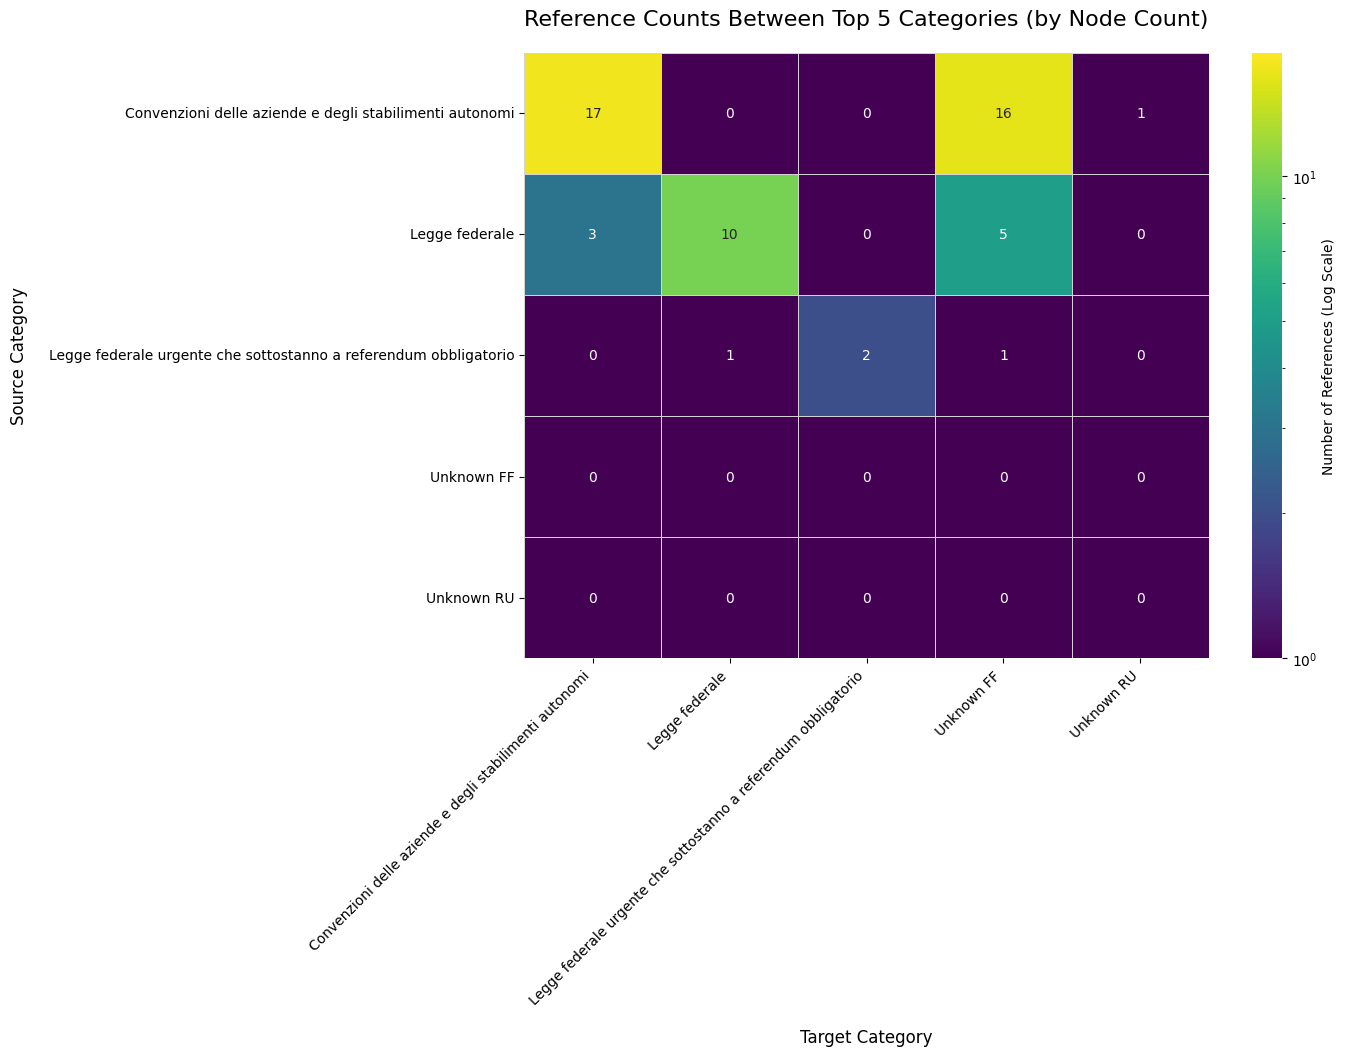

In [13]:
import json
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm # Import LogNorm for the color scale

def create_category_heatmap(summary_data_path, output_image_path, top_n=10):
    """
    Generates a heatmap visualizing reference counts between the top N categories.

    Args:
        summary_data_path (str): Path to the final_category_summary.json file.
        output_image_path (str): Path to save the generated heatmap image (e.g., 'heatmap.png').
        top_n (int): Number of top categories to include in the heatmap.
    """
    # --- 1. Load Data ---
    print(f"Loading category summary from: {summary_data_path}")
    try:
        with open(summary_data_path, 'r', encoding='utf-8') as f:
            summary_data = json.load(f)
        if not isinstance(summary_data, list) or not summary_data:
            print("Error: Summary data is empty or not a list.")
            return
    except FileNotFoundError:
        print(f"Error: Summary file not found at {summary_data_path}")
        return
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {summary_data_path}")
        return
    except Exception as e:
        print(f"An unexpected error occurred during loading: {e}")
        return

    # --- 2. Identify Top N Categories ---
    # Sort by node_count descending
    try:
        sorted_categories = sorted(summary_data, key=lambda x: x.get('node_count', 0), reverse=True)
    except Exception as e:
        print(f"Error sorting categories (check format of 'node_count'): {e}")
        return

    actual_top_n = min(top_n, len(sorted_categories))
    if actual_top_n == 0:
        print("No categories found in the summary data.")
        return
    elif actual_top_n < top_n:
        print(f"Warning: Only found {actual_top_n} categories, using that number for the heatmap.")

    top_categories_data = sorted_categories[:actual_top_n]
    top_category_names = [cat['category_name'] for cat in top_categories_data]
    print(f"Selected Top {actual_top_n} categories (by node_count): {top_category_names}")

    # --- 3. Create Reference Matrix ---
    # Initialize an empty DataFrame with top categories as index and columns
    ref_matrix = pd.DataFrame(0, index=top_category_names, columns=top_category_names, dtype=int)

    # Create a lookup dictionary for faster access
    summary_dict = {cat['category_name']: cat for cat in summary_data}

    # Populate the matrix
    for source_cat_name in top_category_names:
        if source_cat_name not in summary_dict:
             print(f"Warning: Source category '{source_cat_name}' from top list not found in summary dict. Skipping.")
             continue

        source_data = summary_dict[source_cat_name]

        # Internal references (diagonal)
        ref_matrix.loc[source_cat_name, source_cat_name] = source_data.get('total_internal_references', 0)

        # External references
        external_refs = source_data.get('external_references_by_target_category', {})
        for target_cat_name, count in external_refs.items():
            # Only include if the target is also in the top N
            if target_cat_name in ref_matrix.columns:
                ref_matrix.loc[source_cat_name, target_cat_name] = count

    print("\nReference Matrix (counts):")
    print(ref_matrix)

    # --- 4. Generate Heatmap ---
    print("\nGenerating heatmap...")

    # Determine min/max values for color scaling, ignoring zeros for log scale minimum
    # Add 1 to all counts before log to handle zeros gracefully
    plot_matrix = ref_matrix + 1
    min_val = 1 # Since we added 1, the minimum value for LogNorm should be 1
    max_val = plot_matrix.max().max()

    # Check if max_val makes sense
    if max_val <= min_val:
        print("Warning: Maximum reference count is <= 1. Log scale might not be effective. Using linear scale.")
        norm = None # Fallback to default linear scale
        cmap = "Blues" # Simple sequential map
    else:
        # Use LogNorm - it maps data range [vmin, vmax] to [0, 1] logarithmically
        norm = LogNorm(vmin=min_val, vmax=max_val, clip=True)
        cmap = "viridis" # Perceptually uniform, good for log data

    # Set figure size (adjust as needed)
    plt.figure(figsize=(14, 11)) # Make it larger

    # Create the heatmap
    ax = sns.heatmap(
        ref_matrix,           # Use original matrix for annotations
        annot=True,           # Show the reference counts in cells
        fmt=".0f",            # Format annotations as integers
        cmap=cmap,            # Colormap
        norm=norm,            # Apply the LogNorm (or linear if norm is None)
        linewidths=.5,        # Add lines between cells
        linecolor='lightgray',
        cbar=True,            # Show the color bar
        cbar_kws={'label': f'Number of References{" (Log Scale)" if norm else ""}'} # Label for color bar
    )

    ax.set_title(f'Reference Counts Between Top {actual_top_n} Categories (by Node Count)', fontsize=16, pad=20)
    ax.set_xlabel('Target Category', fontsize=12, labelpad=15)
    ax.set_ylabel('Source Category', fontsize=12, labelpad=15)

    # Improve label readability
    plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate x-axis labels
    plt.yticks(rotation=0, fontsize=10) # Keep y-axis labels horizontal

    # Adjust layout to prevent labels overlapping
    plt.tight_layout(rect=[0, 0, 1, 0.97]) # Leave space for title

    # --- 5. Save Heatmap ---
    try:
        plt.savefig(output_image_path, dpi=150) # Increase DPI for better resolution
        print(f"Heatmap saved successfully to: {output_image_path}")
    except Exception as e:
        print(f"Error saving heatmap image: {e}")

    # Display the plot (optional, comment out if running in a non-GUI environment)
    plt.show()


# --- Main execution block ---
if __name__ == "__main__":
    # --- Paths ---
    # !! IMPORTANT: Make sure this path points to the output of the AGGREGATION script !!
    summary_file = "final_category_summary.json"
    # Desired output image file name
    heatmap_image_file = "category_references_heatmap.png"

    # --- Create dummy summary file for demonstration if it doesn't exist ---
    if not os.path.exists(summary_file):
        print(f"Creating dummy file: {summary_file}")
        # Use the sample output from the previous step's description
        dummy_summary_data = [
            {
                "category_name": "Convenzioni delle aziende e degli stabilimenti autonomi",
                "node_count": 9,
                "total_internal_references": 17,
                "external_references_by_target_category": {
                    "Unknown FF": 16,
                    "Unknown RU": 1
                }
            },
            {
                "category_name": "Legge federale urgente che sottostanno a referendum obbligatorio",
                "node_count": 1,
                "total_internal_references": 2,
                "external_references_by_target_category": {
                    "Legge federale": 1,
                    "Unknown FF": 1
                }
            },
             { # Add a few more for a slightly more interesting heatmap
                "category_name": "Legge federale",
                "node_count": 5, # Example node count
                "total_internal_references": 10,
                "external_references_by_target_category": {
                    "Convenzioni delle aziende e degli stabilimenti autonomi": 3,
                    "Unknown FF": 5
                }
            },
             {
                "category_name": "Unknown FF",
                "node_count": 0, # Representing it wasn't a source node itself
                "total_internal_references": 0,
                "external_references_by_target_category": {}
            },
             {
                "category_name": "Unknown RU",
                "node_count": 0,
                "total_internal_references": 0,
                "external_references_by_target_category": {}
            }
        ]
        with open(summary_file, 'w', encoding='utf-8') as f:
            json.dump(dummy_summary_data, f, indent=4, ensure_ascii=False)
    # --- End of dummy file creation ---

    # --- Run the heatmap creation ---
    create_category_heatmap(summary_file, heatmap_image_file, top_n=10)

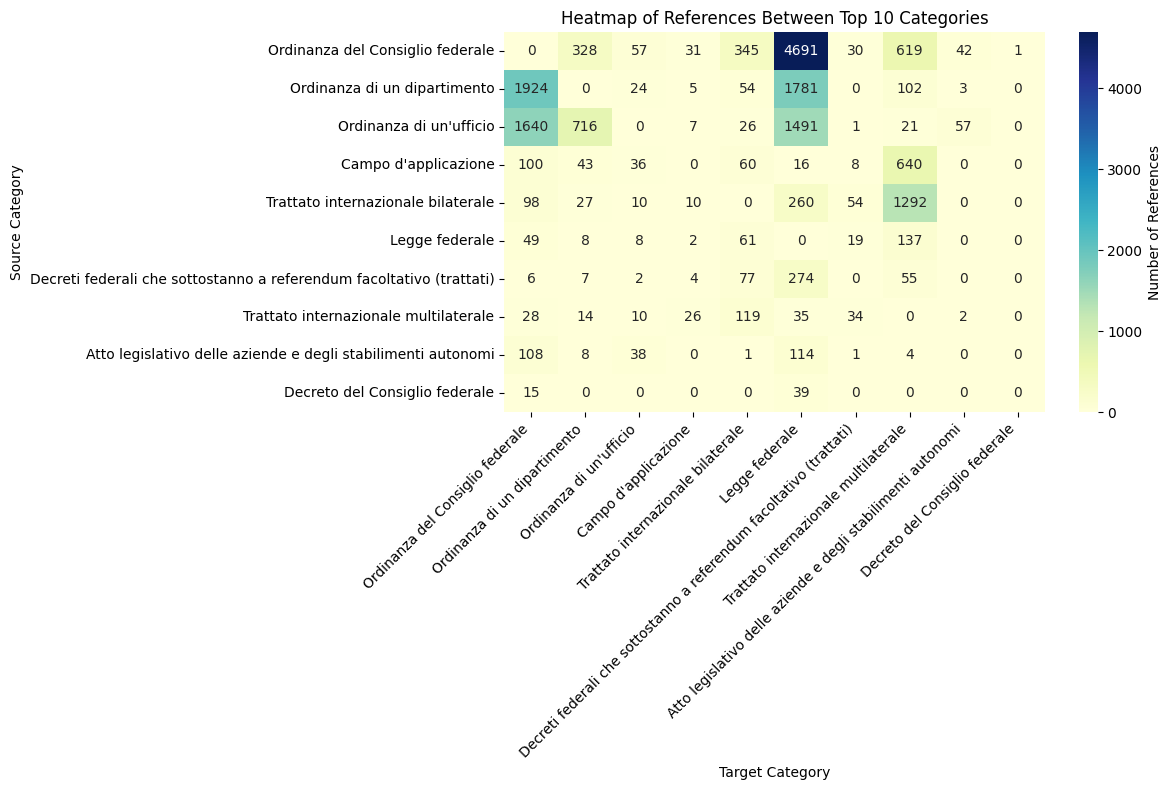

In [15]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
with open("./raw_data/final_category_summary.json", "r") as file:
    data = json.load(file)

# Create a DataFrame to store category names and total number of external references
category_external_refs = []

for entry in data:
    category = entry["category_name"]
    external_refs = sum(entry.get("external_references_by_target_category", {}).values())
    category_external_refs.append((category, external_refs))

# Convert to DataFrame and get top 10 categories with most external references
df_refs = pd.DataFrame(category_external_refs, columns=["category", "external_references"])
top_categories = df_refs.sort_values(by="external_references", ascending=False).head(10)["category"].tolist()

# Create a matrix for heatmap (source -> target references)
matrix = pd.DataFrame(0, index=top_categories, columns=top_categories)

# Populate the matrix
for entry in data:
    source = entry["category_name"]
    if source not in top_categories:
        continue
    targets = entry.get("external_references_by_target_category", {})
    for target, count in targets.items():
        if target in top_categories:
            matrix.loc[source, target] += count

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matrix, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "Number of References"})
plt.title("Heatmap of References Between Top 10 Categories")
plt.ylabel("Source Category")
plt.xlabel("Target Category")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [16]:
import json
import pandas as pd
import numpy as np
import networkx as nx
import plotly.graph_objects as go

# Load the data
with open("./raw_data/final_category_summary.json", "r") as file:
    data = json.load(file)

# Determine top 10 categories by external references
category_external_refs = [(entry["category_name"], sum(entry.get("external_references_by_target_category", {}).values())) for entry in data]
df_refs = pd.DataFrame(category_external_refs, columns=["category", "external_references"])
top_categories = df_refs.sort_values(by="external_references", ascending=False).head(10)["category"].tolist()

# Build adjacency matrix for top categories
matrix = pd.DataFrame(0, index=top_categories, columns=top_categories)
for entry in data:
    source = entry["category_name"]
    if source in top_categories:
        for target, count in entry.get("external_references_by_target_category", {}).items():
            if target in top_categories:
                matrix.loc[source, target] += count

# Circle layout positions
angle = np.linspace(0, 2 * np.pi, len(top_categories), endpoint=False)
positions = {cat: (np.cos(a), np.sin(a)) for cat, a in zip(top_categories, angle)}

# Create directed graph
G = nx.DiGraph()
category_sizes = df_refs.set_index("category").loc[top_categories]["external_references"]

for cat in top_categories:
    G.add_node(cat, size=category_sizes[cat], pos=positions[cat])
for src in top_categories:
    for tgt in top_categories:
        if matrix.loc[src, tgt] > 0:
            G.add_edge(src, tgt, weight=matrix.loc[src, tgt])

# Build Plotly graph
edge_x, edge_y = [], []
for src, tgt in G.edges():
    x0, y0 = G.nodes[src]['pos']
    x1, y1 = G.nodes[tgt]['pos']
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

node_x = [G.nodes[n]['pos'][0] for n in G.nodes]
node_y = [G.nodes[n]['pos'][1] for n in G.nodes]
node_sizes = [G.nodes[n]['size'] for n in G.nodes]

node_trace = go.Scatter(
    x=node_x, y=node_y,
    text=list(G.nodes),
    mode='markers+text',
    textposition="top center",
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='YlGnBu',
        size=[s / 10 for s in node_sizes],
        color=node_sizes,
        colorbar=dict(title='External References'),
        line_width=2))

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=1, color='#888'),
    hoverinfo='none',
    mode='lines')

fig = go.Figure(data=[edge_trace, node_trace],
    layout=go.Layout(
        title='Top 10 Categories Reference Graph',
        showlegend=False,
        hovermode='closest',
        margin=dict(b=20, l=5, r=5, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)))

fig.write_html("top_10_category_graph.html")


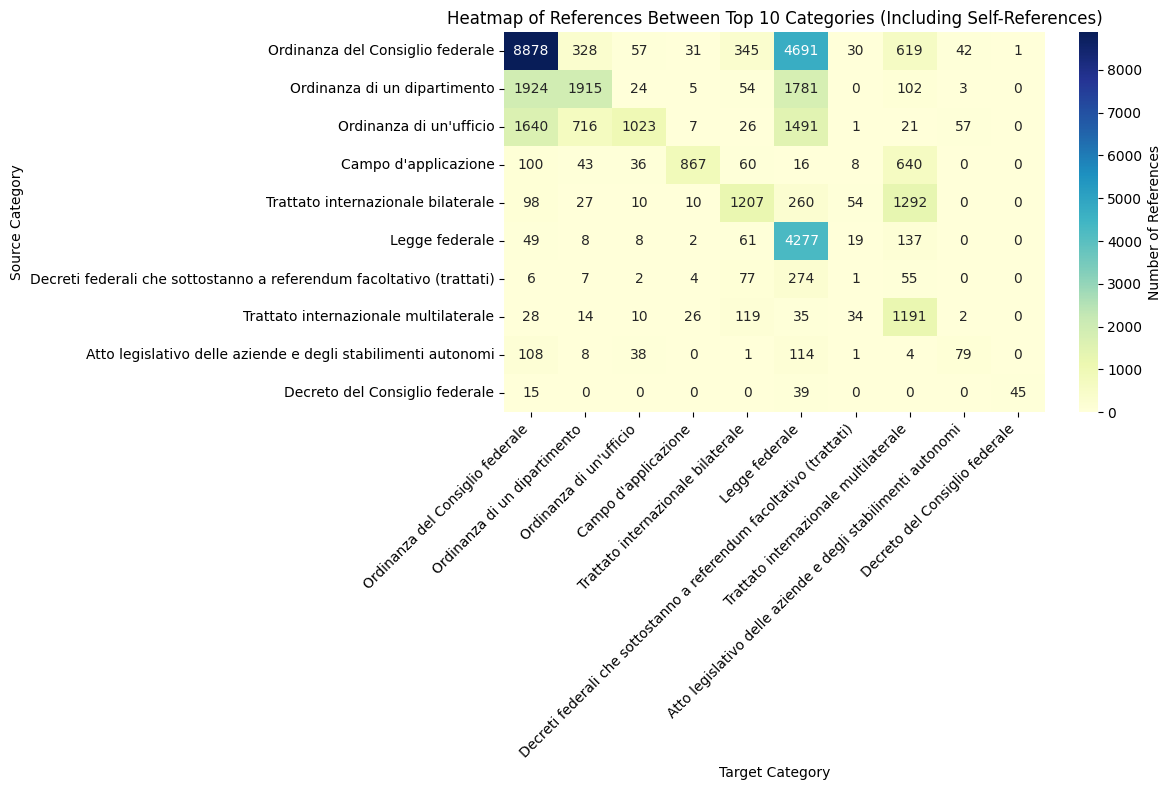

In [17]:
# Fix the issue by reloading the data (was previously modified)
with open("./raw_data/final_category_summary.json", "r") as file:
    data = json.load(file)

# Rebuild the matrix from scratch including self-references
matrix = pd.DataFrame(0, index=top_categories, columns=top_categories)

for entry in data:
    source = entry["category_name"]
    if source not in top_categories:
        continue

    # Add internal (self) references
    matrix.loc[source, source] = entry.get("total_internal_references", 0)

    # Add external references
    for target, count in entry.get("external_references_by_target_category", {}).items():
        if target in top_categories:
            matrix.loc[source, target] += count

# Plot heatmap with self-references included
plt.figure(figsize=(12, 8))
sns.heatmap(matrix, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "Number of References"})
plt.title("Heatmap of References Between Top 10 Categories (Including Self-References)")
plt.ylabel("Source Category")
plt.xlabel("Target Category")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
